# SLD pipeline inference (local): final models on 10 unseen test sheets

Loads the already-trained detector (`models/sld_yolov8s.pt`) and classifier (`Component Training/models/custom_best.keras`) and re-runs detect → trace wires → re-label on 10 sheets from the test split. No training, no Kaggle, no repo cloning — everything is read straight from the local checkout.

**Before running**: `pip install ultralytics scikit-image networkx tensorflow` in your local Python env. Dataset (`Data/sld-sheets/`) and models must already be in place (they are, in this checkout).

In [1]:
import json
import sys
from pathlib import Path

from PIL import Image

SLD_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
COMP_DIR = SLD_DIR.parent / "Component Training"
N_SHEETS = 10

sys.path.insert(0, str(SLD_DIR))
assert (SLD_DIR / "predict_graph.py").exists(), f"expected SLD Training dir, got {SLD_DIR}"

## Load classes, pick 10 test sheets

In [2]:
import config
from sld_data import load_classes, sheet_ids, image_path, load_graph
from predict_graph import load_detector, predict_sheet
from reclassify import load_classifier, reclassify
from graph_eval import score_sheet, summarise
from viz import show_graph

classes = load_classes()
test_ids = sheet_ids("test")[:N_SHEETS]
len(classes), test_ids

(23,
 ['GEN-0025',
  'GEN-0030',
  'GEN-0045',
  'GEN-0075',
  'GEN-0076',
  'GEN-0079',
  'GEN-0093',
  'GEN-0139',
  'GEN-0147',
  'GEN-0176'])

## Load the final models (already on disk locally)

In [3]:
detector = load_detector(config.MODEL_DIR / "sld_yolov8s.pt")
classifier = load_classifier(COMP_DIR / "models" / "custom_best.keras")

## Detect → trace wires → re-label, then score against ground truth

In [4]:
def recover(sid):
    img = Image.open(image_path(sid, "test"))
    result, graph = predict_sheet(detector, img, classes, sid)
    reclassify(img, result["symbols"], classifier)
    return img, result


recovered = {sid: recover(sid) for sid in test_ids}
rows = [score_sheet(load_graph(sid), recovered[sid][1]) for sid in test_ids]

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\triton\windows_utils.py:404: UserWarning: Failed to find CUDA.
  warnings.warn("Failed to find CUDA.")
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\triton\knobs.py:212: UserWarning: Failed to find cuobjdump.exe
  warnings.warn(f"Failed to find {binary}")
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\triton\knobs.py:212: UserWarning: Failed to find nvdisasm.exe
  warnings.warn(f"Failed to find {binary}")


## Accuracy on these 10 sheets

In [5]:
print(json.dumps(summarise(rows), indent=2))

{
  "sheets": 10,
  "node_precision": 1.0,
  "node_recall": 0.9481865284974094,
  "edge_precision": 0.8653846153846154,
  "edge_recall": 0.7377049180327869,
  "edge_type_accuracy": 1.0,
  "net_jaccard": 0.9419279516779516
}


## Detected + traced graph on each of the 10 sheets

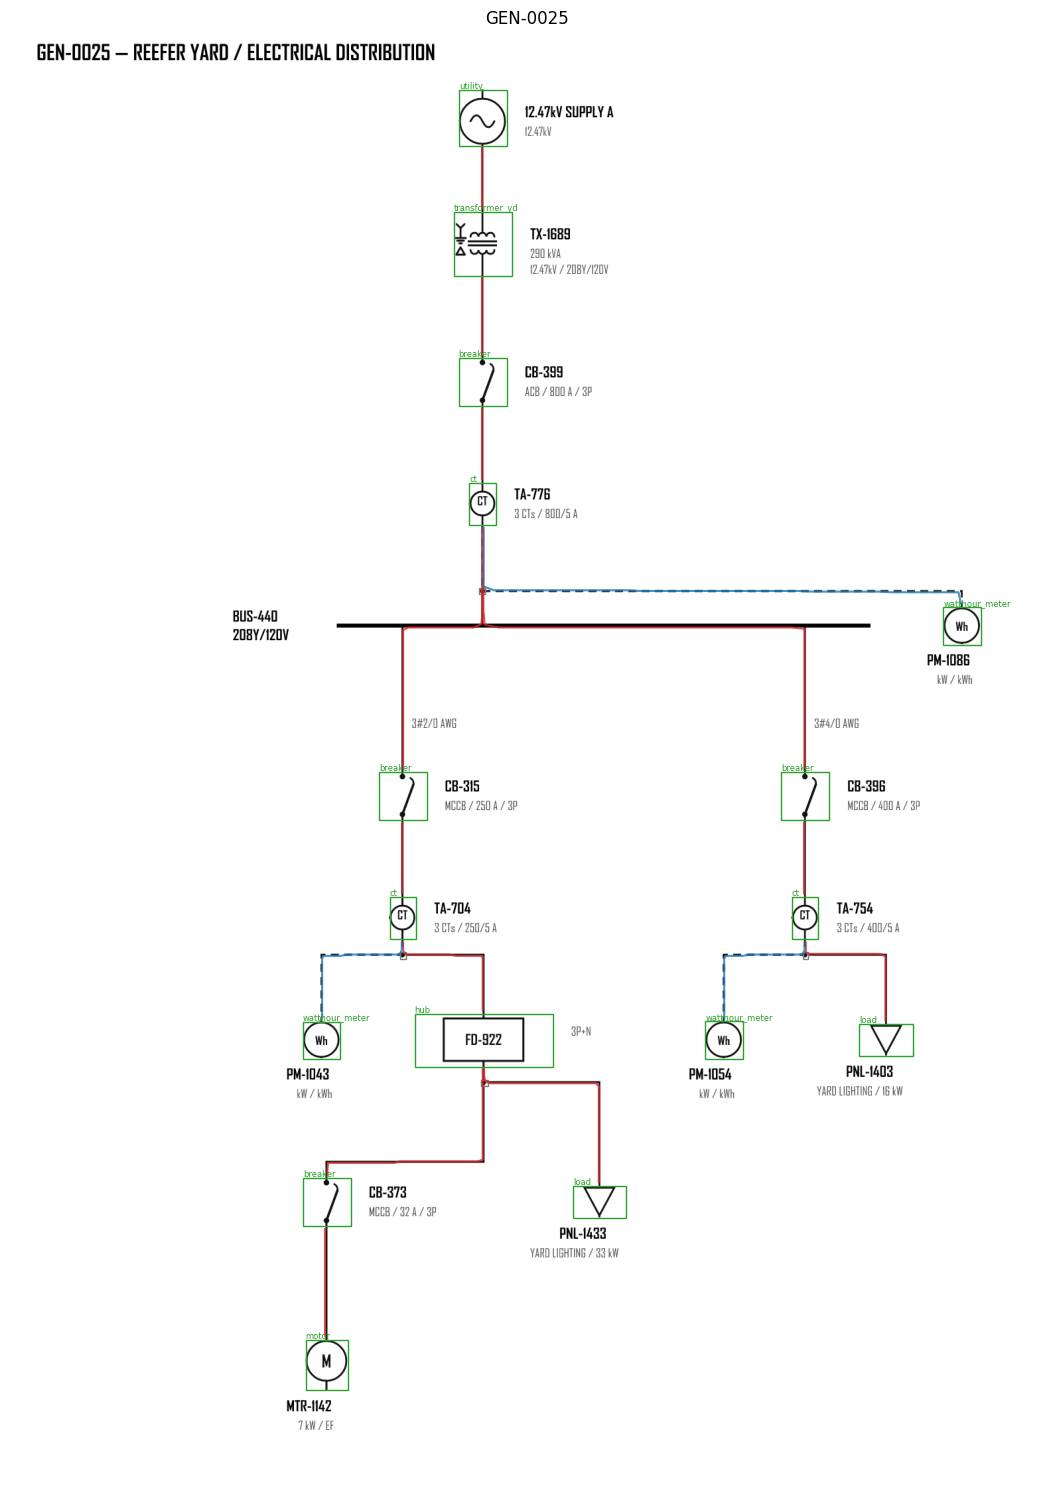

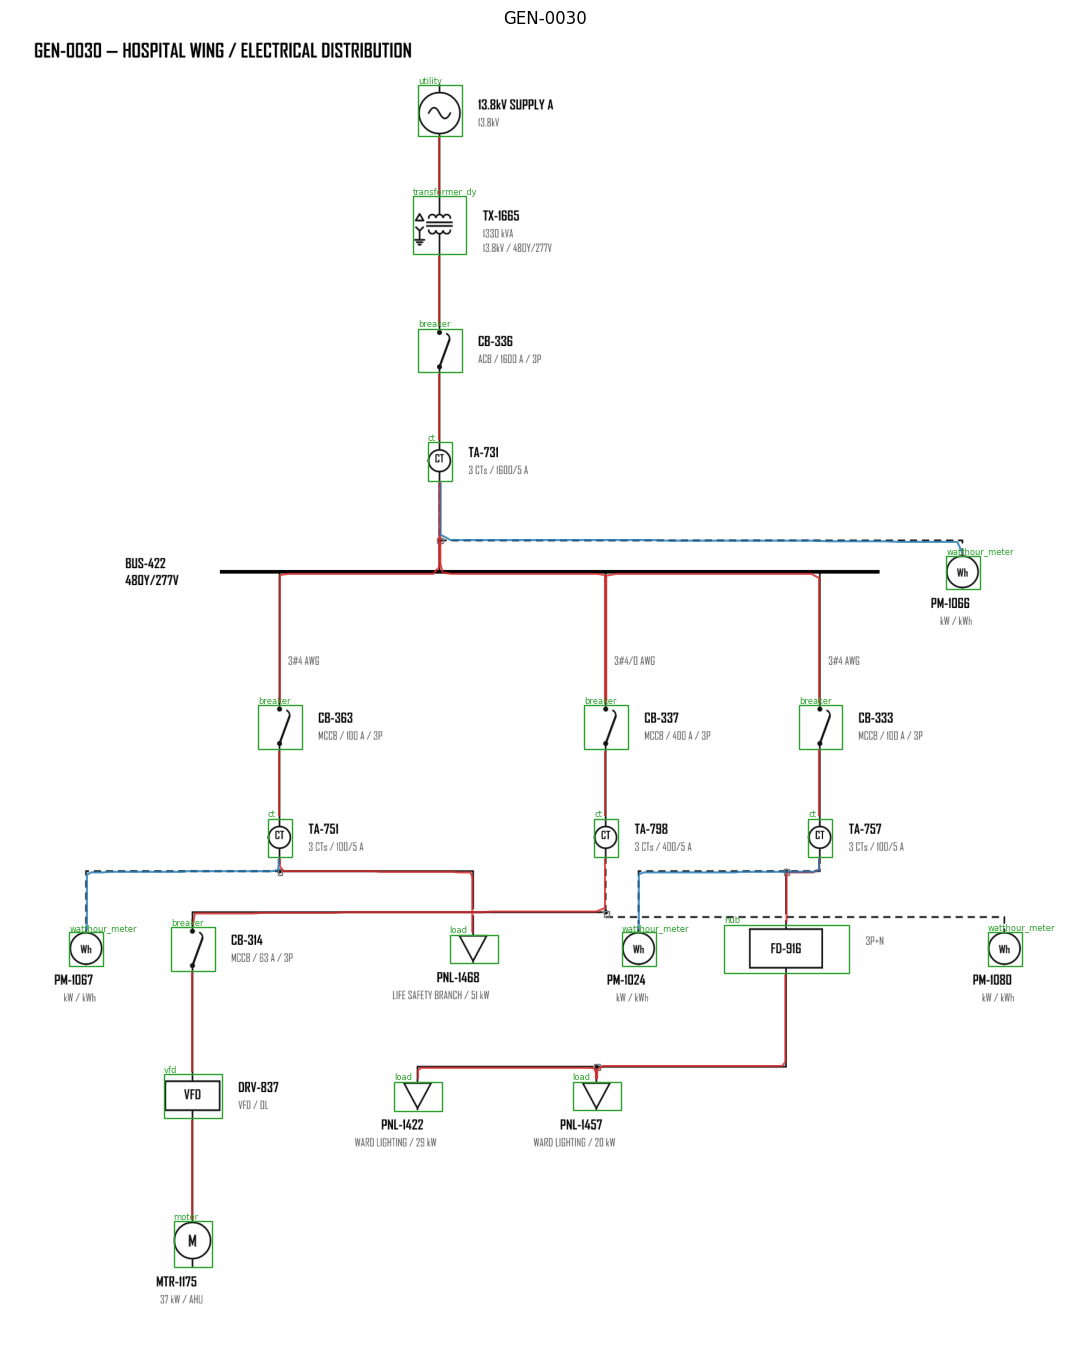

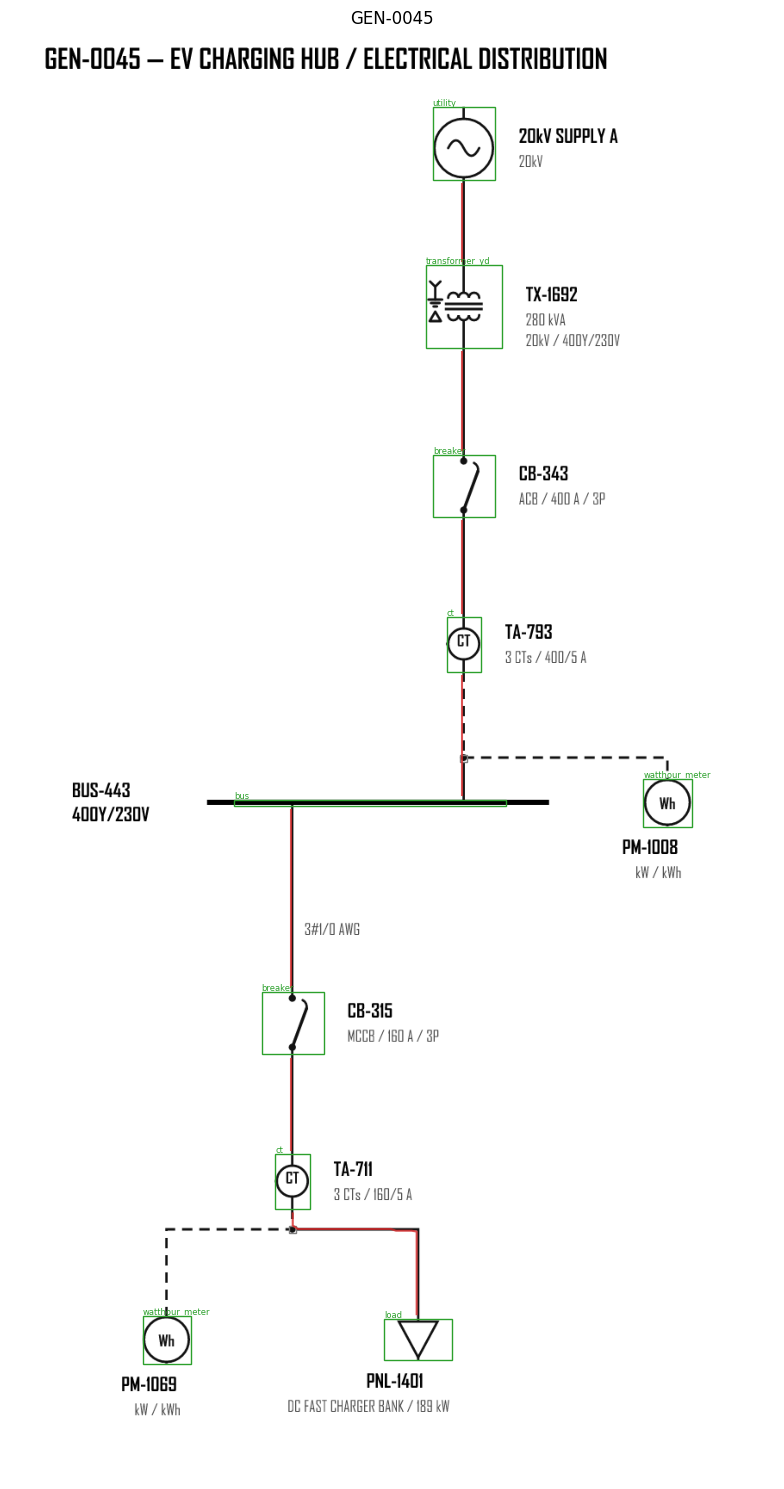

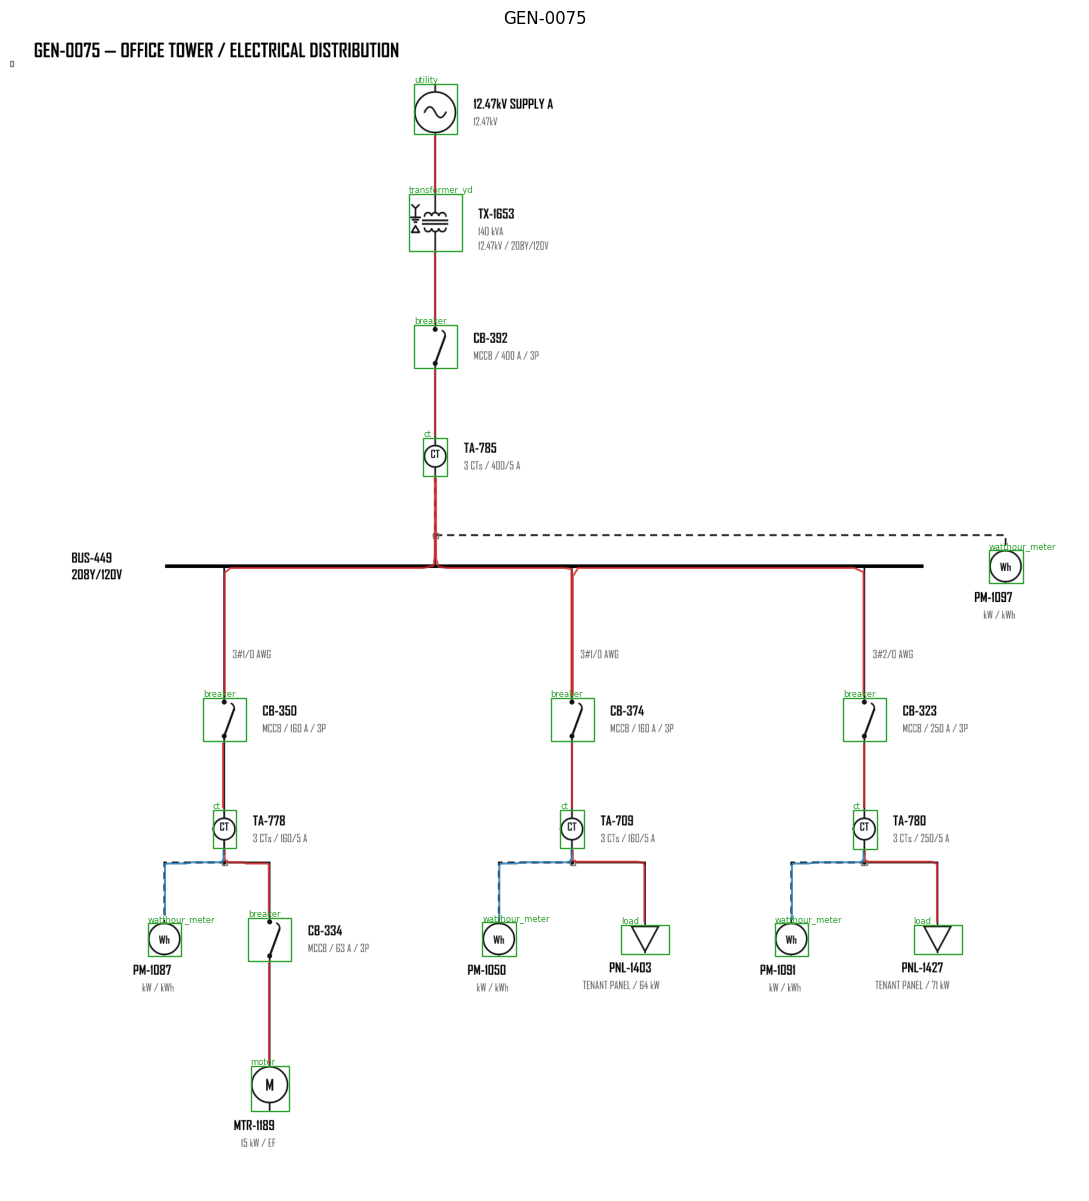

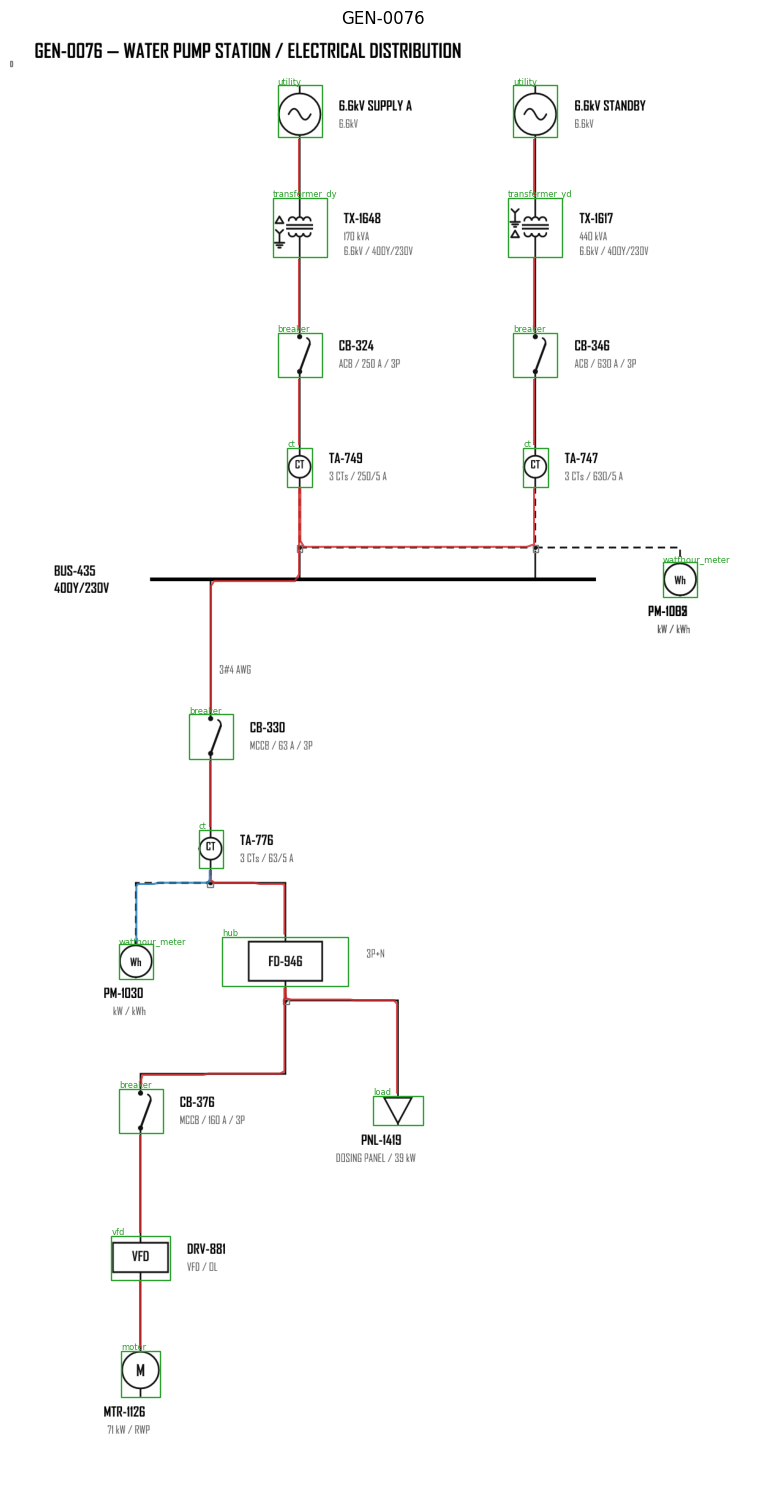

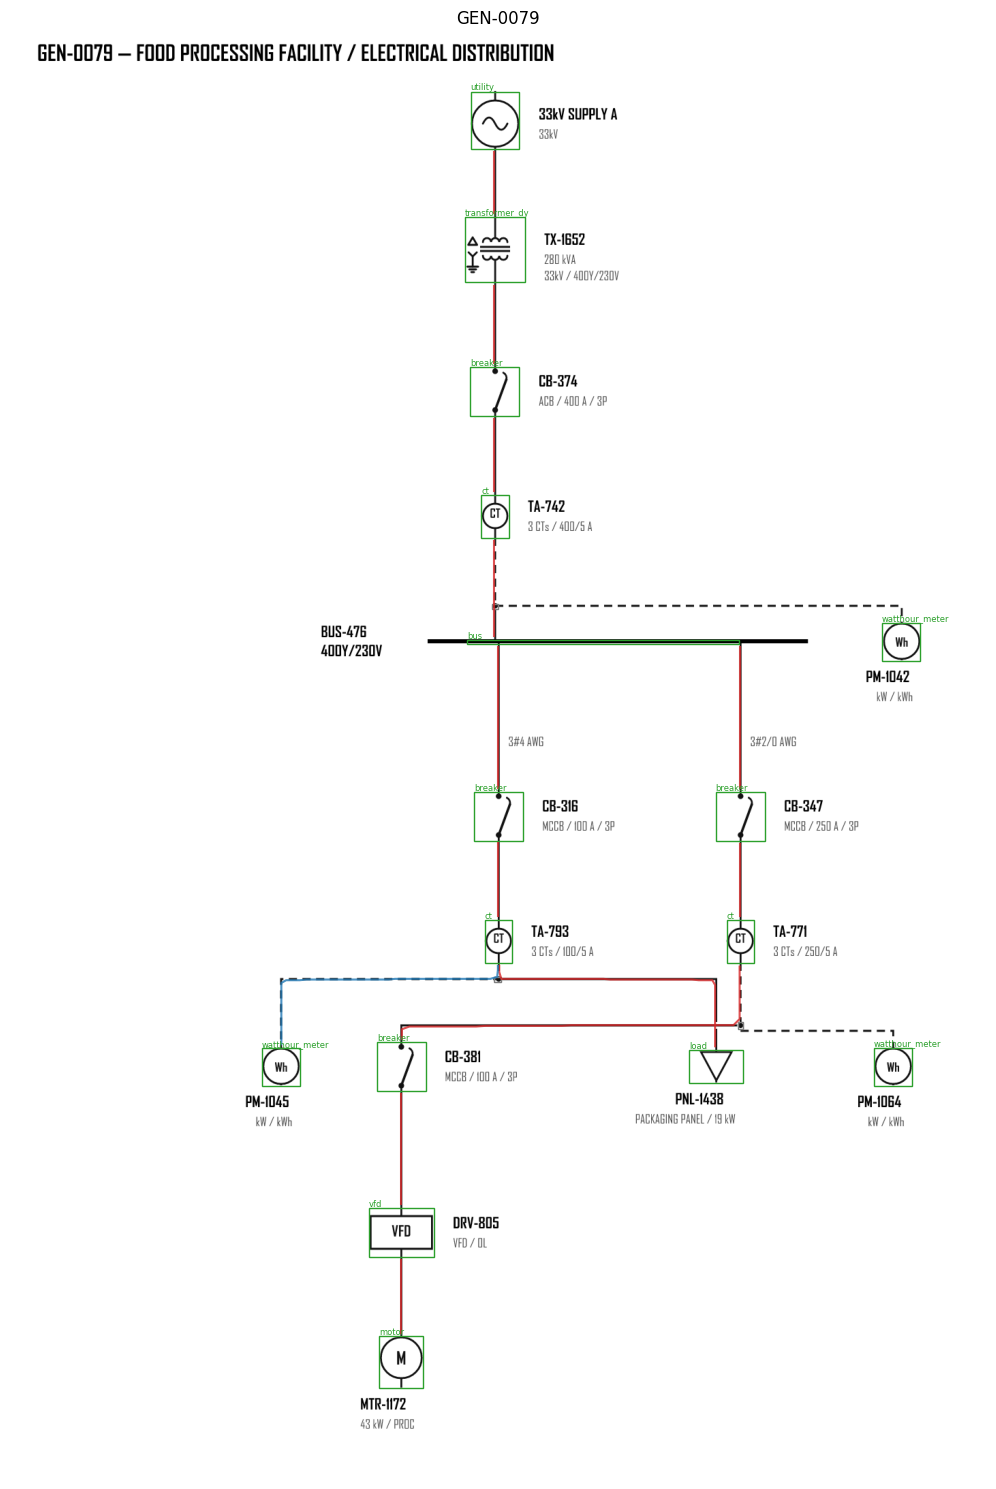

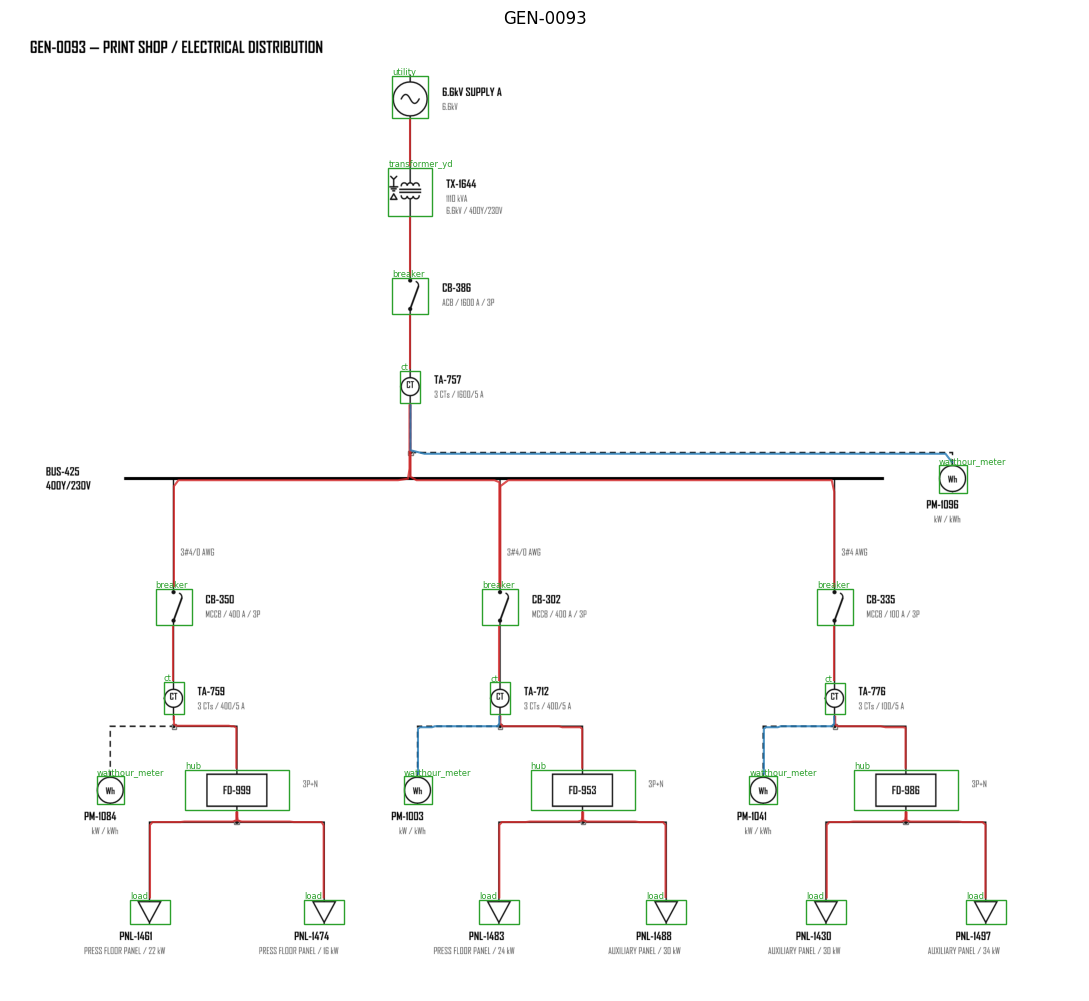

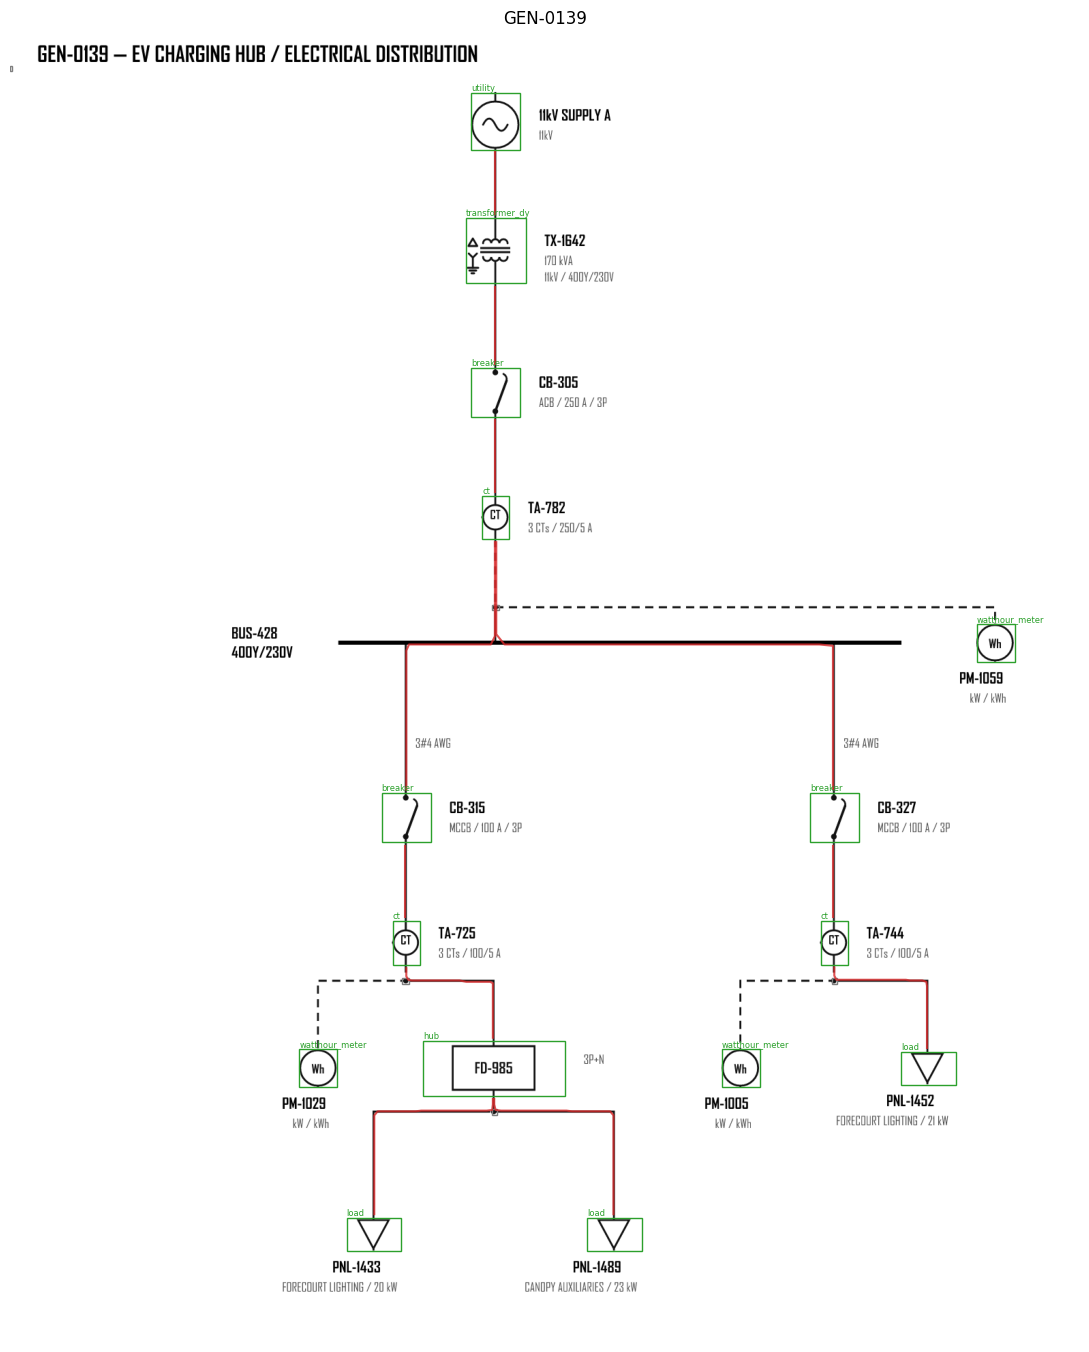

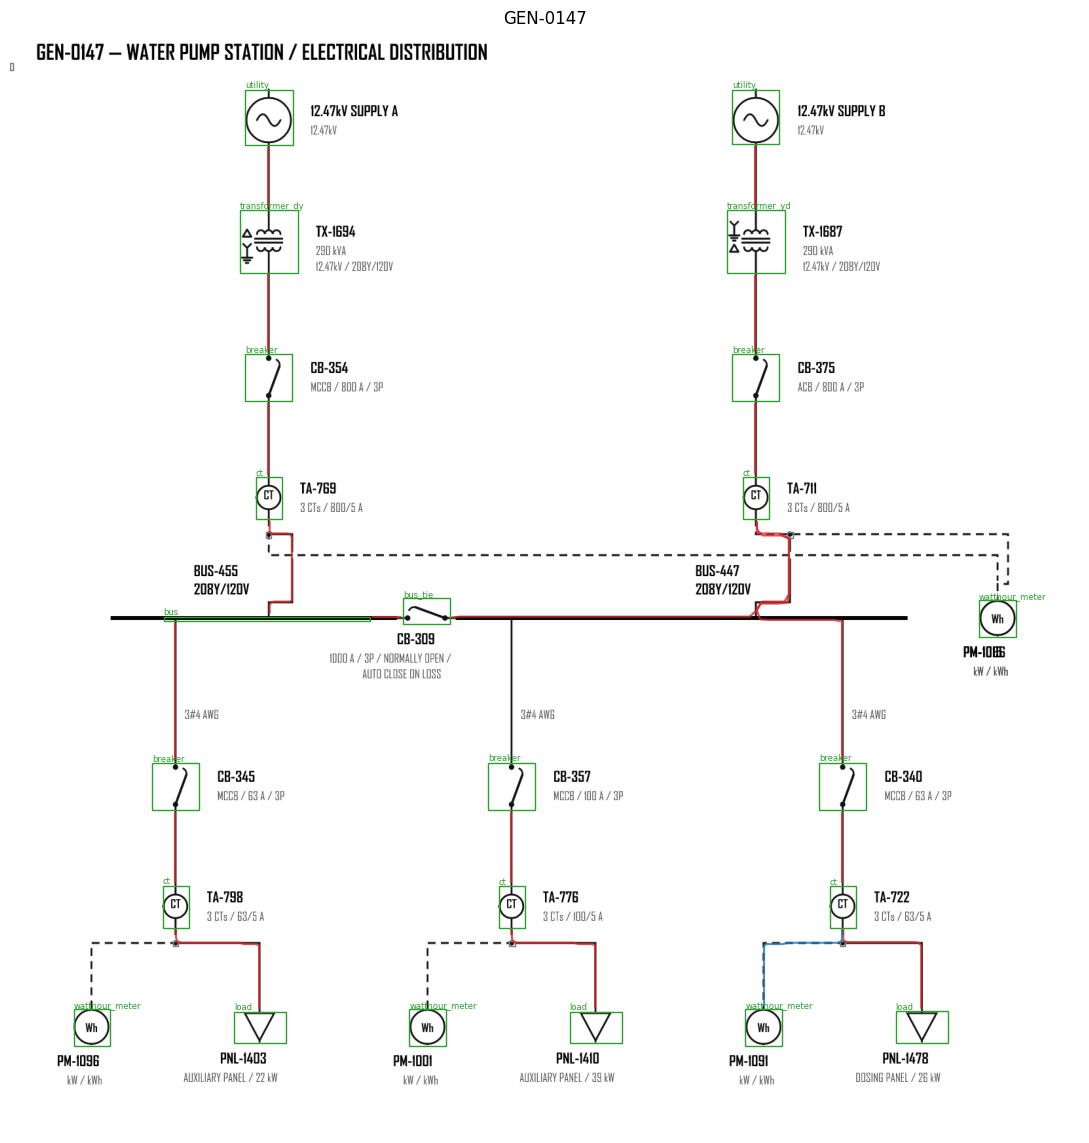

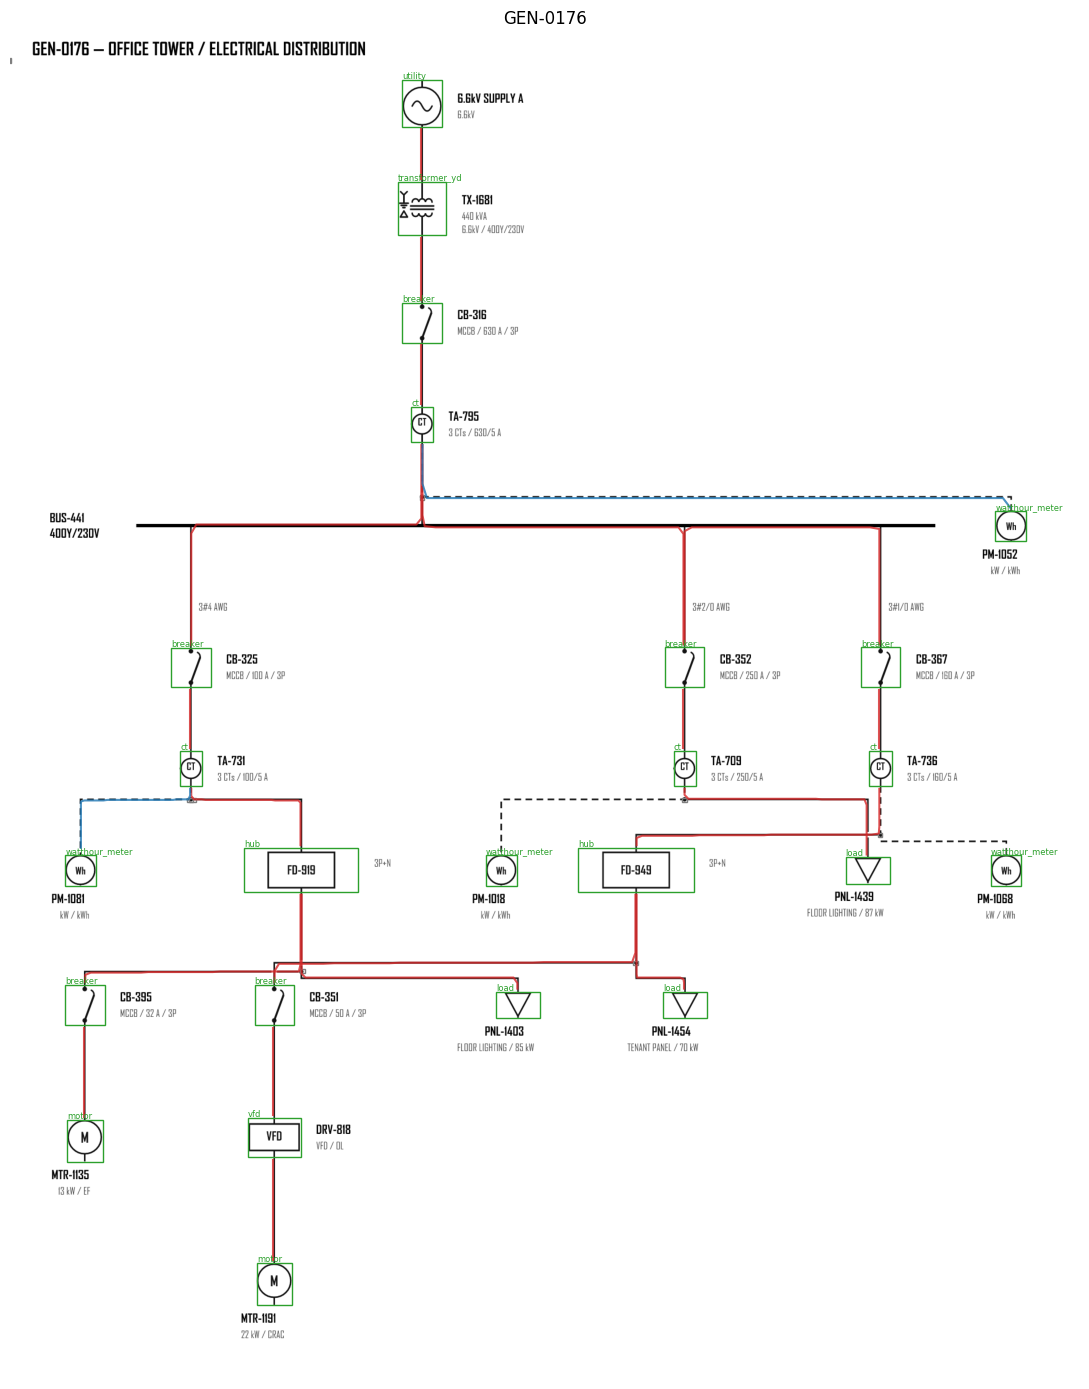

In [6]:
for sid in test_ids:
    img, result = recovered[sid]
    show_graph(img, result, sid)

## Real sheets: `Data/Electric Sample Data/Test1/` (3 images)

These are real, scanned sheets with no ground-truth `graph.json`, so there is nothing to score against — this just runs detect → trace → re-label and shows the recovered graph, to see how the synthetic-trained pipeline transfers to a real sheet.

In [7]:
REAL_TEST_DIR = SLD_DIR.parents[2] / "Data" / "Electric Sample Data" / "Test1"
real_paths = sorted(REAL_TEST_DIR.glob("*.png"))
real_paths

[WindowsPath('f:/FYP/Data/Electric Sample Data/Test1/T2.png'),
 WindowsPath('f:/FYP/Data/Electric Sample Data/Test1/T3-2.png'),
 WindowsPath('f:/FYP/Data/Electric Sample Data/Test1/T3.png')]

In [8]:
def recover_image(img):
    result, graph = predict_sheet(detector, img, classes)
    reclassify(img, result["symbols"], classifier)
    return result


real_recovered = {}
for p in real_paths:
    img = Image.open(p).convert("RGB")
    real_recovered[p.stem] = (img, recover_image(img))
    n_sym, n_edge, n_net = (len(real_recovered[p.stem][1][k]) for k in ("symbols", "edges", "nets"))
    print(f"{p.name}: {n_sym} symbols, {n_edge} edges, {n_net} nets")

T2.png: 6 symbols, 2 edges, 4 nets
T3-2.png: 4 symbols, 3 edges, 3 nets
T3.png: 0 symbols, 0 edges, 0 nets


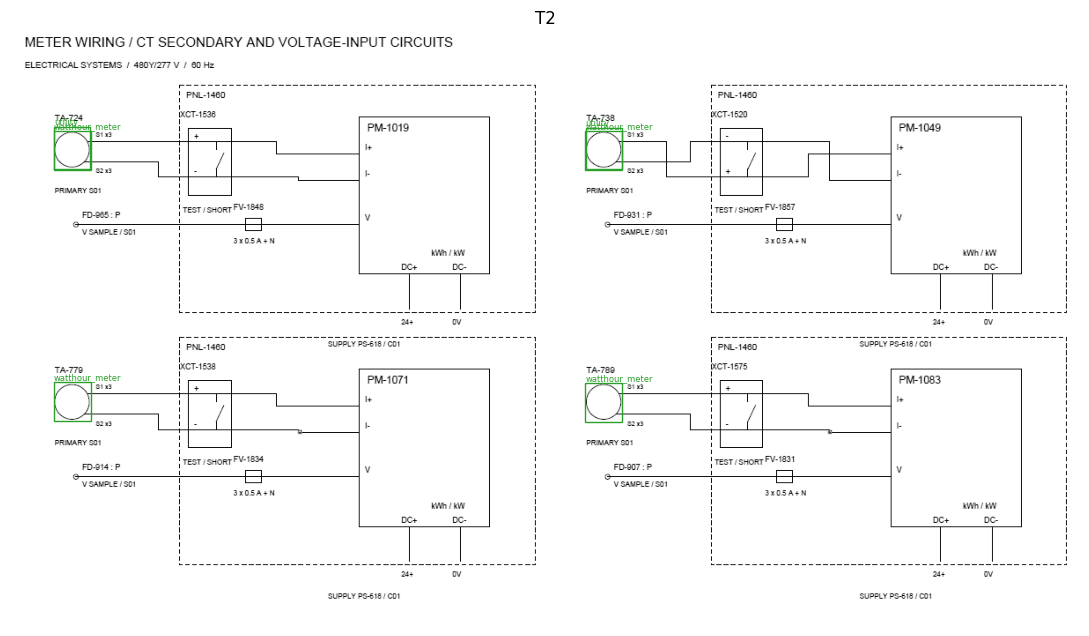

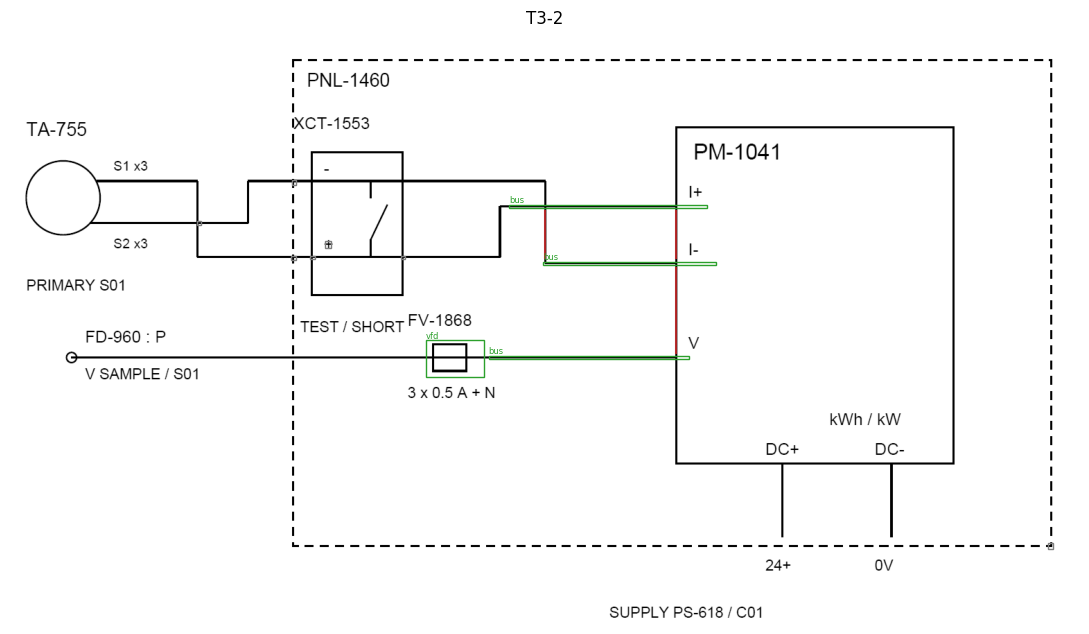

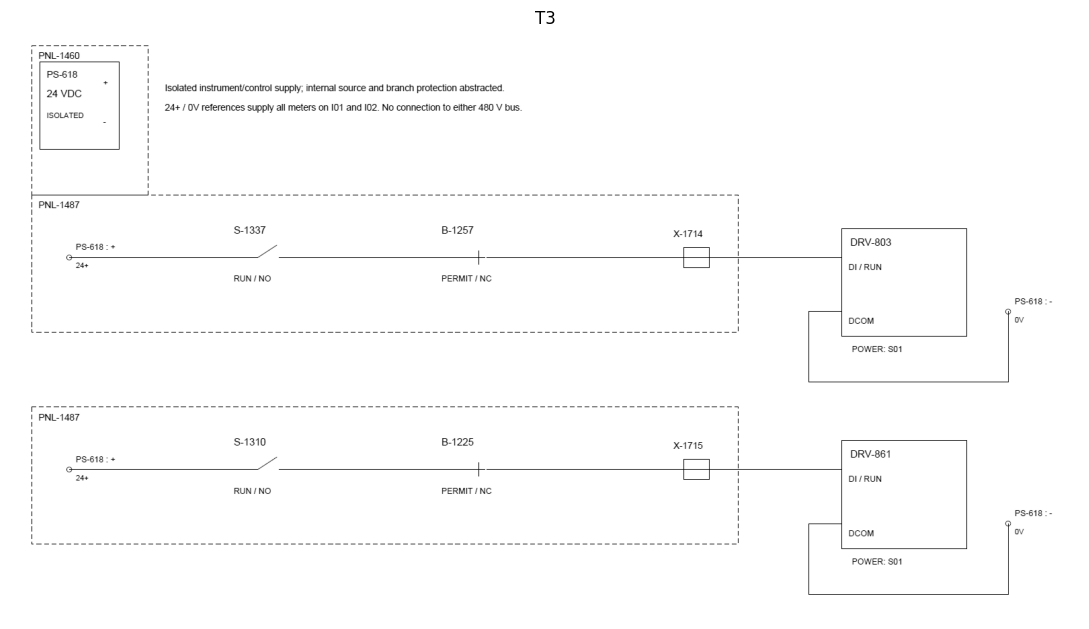

In [9]:
for name, (img, result) in real_recovered.items():
    show_graph(img, result, name)